# Fellegi-Sunter from first principles

The previous notebook ended with three complaints about deterministic rules:
partial agreement is invisible, every agreement weighs the same regardless of how
common the value is, and the only way to move along the precision/recall
trade-off is to write another rule.

This notebook fixes all three, using nothing but counting. It builds the
Fellegi-Sunter framework by hand — no linkage library — so that when
[chapter 2.6](implementing-in-splink.md) hands the work to Splink, you know
exactly what Splink is doing.

**What you will do**

1. Define the two questions that turn an agreement into evidence
2. Estimate *m* and *u* for each field by direct counting
3. Convert them into match weights, and read what the weights say
4. Score real pairs, and see the two populations separate
5. Choose a threshold and measure the consequence
6. Check the assumption the whole framework rests on, and find it violated

**One thing to be clear about.** Below, *m* is estimated using the known truth.
You will not have that. Chapter 2.6 shows how *m* is estimated without it, using
expectation-maximisation. Computing it directly here is what makes the quantity
concrete before it becomes an algorithm.

## 0. Setup and prepared data

In [1]:
import unicodedata
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 130)

DATA = Path("../../data")
if not DATA.exists():
    DATA = Path("data")

fonasa = pd.read_csv(DATA / "fonasa_sample.csv", dtype=str)
suseso = pd.read_csv(DATA / "suseso_sample.csv", dtype=str)


def basic_text_clean(series):
    return (series.astype("string").str.strip().str.upper()
            .str.replace(r"\s+", " ", regex=True))


def remove_accents(value):
    if pd.isna(value):
        return pd.NA
    value = unicodedata.normalize("NFKD", str(value))
    return "".join(c for c in value if not unicodedata.combining(c))


def standardise_name(series):
    cleaned = basic_text_clean(series)
    cleaned = cleaned.map(remove_accents, na_action="ignore").astype("string")
    cleaned = cleaned.str.replace(r"[^A-ZN ]", "", regex=True)
    return cleaned.str.replace(r"\s+", " ", regex=True).str.strip()


def clean_sex(series):
    cleaned = basic_text_clean(series)
    return cleaned.replace({"HOMBRE": "M", "MUJER": "F", "MASCULINO": "M",
                            "FEMENINO": "F", "": pd.NA})


for df in (fonasa, suseso):
    for col in ["nombre", "ap1", "ap2"]:
        df[f"{col}_clean"] = standardise_name(df[col])
    df["sexo_clean"] = clean_sex(df["sexo"])
    df["nac_clean"] = basic_text_clean(df["nacionalidad"])

CLEAN = ["nombre_clean", "ap1_clean", "ap2_clean", "sexo_clean", "nac_clean"]
TRUE_MATCHES = 4500

print(f"fonasa: {len(fonasa):,} records | suseso: {len(suseso):,} records")
print(f"true matches present in the data: {TRUE_MATCHES:,}")

fonasa: 30,000 records | suseso: 27,000 records
true matches present in the data: 4,500


## 1. The two questions

Take any single field — say the first surname — and any pair of records that
agree on it. Fellegi and Sunter's insight was that the evidential value of that
agreement depends on two probabilities, and only on those two.

**The *m*-probability.** *Given that this pair really is the same person, how
often does this field agree?* This is about **data quality**. A field that is
recorded accurately and consistently has a high *m*. A field full of typing
errors, abbreviations and missing values has a low one.

**The *u*-probability.** *Given that this pair is two different people, how often
does this field agree anyway, by coincidence?* This is about **discriminating
power**. Sex agrees by chance about half the time, so its *u* is about 0.5. A
surname agrees by chance very rarely, so its *u* is tiny.

The ratio of the two is what matters:

$$\text{likelihood ratio} = \frac{m_j}{u_j}$$

A field with a high *m* and a low *u* — accurate and discriminating — produces a
large ratio, and agreement on it is strong evidence. A field with a high *u* —
sex, nationality — produces a ratio near 1, and agreement on it is barely
evidence at all.

This is the whole idea. Everything else is bookkeeping.

## 2. The two comparison populations

To estimate *m* we need pairs we know are matches. To estimate *u* we need pairs
we know are not.

The 4,500 true matches give us the first. For the second, we sample pairs at
random from the two registers: with 810 million possible pairs and only 4,500
true ones, a random pair is a non-match with probability 0.999994, so a random
sample is a clean estimate of the non-match population.

In [2]:
import numpy as np

rng = np.random.default_rng(42)

# --- matches: the 4,500 pairs that share a true_person_id -------------------
matches = (
    fonasa.merge(suseso, on="true_person_id", suffixes=("_f", "_s"))
    [["true_person_id"] + [f"{c}_{s}" for c in CLEAN for s in ("f", "s")]]
)

# --- non-matches: a random sample of record pairs ---------------------------
N_SAMPLE = 200_000
idx_f = rng.integers(0, len(fonasa), N_SAMPLE)
idx_s = rng.integers(0, len(suseso), N_SAMPLE)

non_matches = pd.concat(
    [fonasa.iloc[idx_f][CLEAN + ["true_person_id"]].add_suffix("_f").reset_index(drop=True),
     suseso.iloc[idx_s][CLEAN + ["true_person_id"]].add_suffix("_s").reset_index(drop=True)],
    axis=1,
)
# Remove any true pair that the random draw happened to hit
accidental = (non_matches["true_person_id_f"] == non_matches["true_person_id_s"])
non_matches = non_matches[~accidental]

print(f"matches      : {len(matches):,} pairs")
print(f"non-matches  : {len(non_matches):,} randomly drawn pairs "
      f"({accidental.sum()} accidental true pairs removed)")

matches      : 4,500 pairs
non-matches  : 199,998 randomly drawn pairs (2 accidental true pairs removed)


## 3. Estimating m and u

"Agreement" needs a definition. We use the simplest one: both values present and
identical. If either value is missing, the field is treated as providing **no
evidence** — neither for nor against — which is how Splink handles it too.

That leaves three outcomes per field per pair: agree, disagree, or no comparison.

In [3]:
def agreement(pairs, field):
    """Return (agree, disagree, missing) boolean masks for one field."""
    left, right = pairs[f"{field}_f"], pairs[f"{field}_s"]
    comparable = left.notna() & right.notna()
    agree = comparable & (left == right)
    disagree = comparable & (left != right)
    return agree, disagree, ~comparable


rows = []
for field in CLEAN:
    a_m, d_m, _ = agreement(matches, field)
    a_u, d_u, _ = agreement(non_matches, field)
    m = a_m.sum() / (a_m.sum() + d_m.sum())      # among comparable match pairs
    u = a_u.sum() / (a_u.sum() + d_u.sum())      # among comparable non-match pairs
    rows.append({"field": field, "m": round(m, 6), "u": round(u, 8)})

mu = pd.DataFrame(rows)
mu

,field,m,u
0,nombre_clean,0.323160,0.000149
1,ap1_clean,0.450928,0.001470
2,ap2_clean,0.437746,0.001770
3,sexo_clean,0.916237,0.500436
4,nac_clean,0.994390,0.670525


Read the two columns separately before combining them.

The ***m*** column is data quality, and here it is **poor**. Among pairs we know
are the same person, the given name agrees exactly only about a third of the
time, and each surname less than half the time. That is a demanding dataset — and
it is the direct explanation of why exact matching in chapter 2.3 found only a
quarter of the matches. It was not doing anything wrong; two thirds of genuine
matches simply do not agree exactly on the given name.

Sex and nationality have much higher *m* values, because a two-valued field
offers little to get wrong.

The ***u*** column is discriminating power, and it spans four orders of
magnitude. Two random people share a given name about once in seven thousand
pairs, a surname about once in seven hundred, a sex about half the time, and a
nationality two thirds of the time.

Neither column alone tells you what a field is worth. Sex has an excellent *m*
and a useless *u*; the given name has a poor *m* and a superb *u*. Only the ratio
settles it.

## 4. From probabilities to weights

The likelihood ratio $m_j/u_j$ multiplies across fields, which is awkward to
read and awkward to sum. Taking a logarithm turns multiplication into addition,
so the evidence from several fields can simply be added up.

By convention base 2 is used, and the result is called a **match weight**, in
units of bits:

$$w_j = \log_2 \frac{m_j}{u_j} \quad \text{when field } j \text{ agrees}$$

$$w_j = \log_2 \frac{1 - m_j}{1 - u_j} \quad \text{when field } j \text{ disagrees}$$

$$w_j = 0 \quad \text{when field } j \text{ cannot be compared}$$

One bit means the pair is twice as likely to be a match as it was before seeing
that field. Agreement weights are positive; disagreement weights are negative.

In [4]:
mu["agree_weight"] = np.log2(mu["m"] / mu["u"]).round(2)
mu["disagree_weight"] = np.log2((1 - mu["m"]) / (1 - mu["u"])).round(2)
mu

,field,m,u,agree_weight,disagree_weight
0,nombre_clean,0.323160,0.000149,11.08,-0.56
1,ap1_clean,0.450928,0.001470,8.26,-0.86
2,ap2_clean,0.437746,0.001770,7.95,-0.83
3,sexo_clean,0.916237,0.500436,0.87,-2.58
4,nac_clean,0.994390,0.670525,0.57,-5.88


This table is the model, and it repays reading closely.

**Agreement on a given name is worth an enormous amount** — far more than
agreement on any other field, because two different people almost never share
one. Agreement on the surnames is worth a great deal too.

**Agreement on sex is worth about one bit**, and agreement on nationality
somewhat less. Exactly as intuition suggested: knowing two records share a sex
barely narrows anything down.

**The disagreement weights invert the picture.** Disagreement on sex is
*strongly negative* — genuine matches almost always agree on sex, so
disagreement is real evidence against the pair — while disagreement on a given
name, although negative, is milder relative to the enormous positive weight,
because genuine matches disagree on names often enough that it happens.

That asymmetry is precisely what a deterministic rule cannot express. It is the
formal version of the non-disagreement clause invented by hand in the previous
notebook, except that here the strength of the clause is measured rather than
guessed.

## 5. Scoring a pair

The total match weight of a pair is the sum of its field weights, plus a term
for the prior odds that any two records drawn at random are a match:

$$W = \log_2 \frac{\lambda}{1-\lambda} + \sum_j w_j$$

where $\lambda$ is the probability that two randomly chosen records match. With
4,500 true matches among 810 million possible pairs, that prior is very small and
its log-odds term is large and negative — which is why a pair needs a lot of
positive evidence before it is worth believing.

In [5]:
lam = TRUE_MATCHES / (len(fonasa) * len(suseso))
prior_weight = np.log2(lam / (1 - lam))

print(f"lambda (prior probability two random records match): {lam:.3e}")
print(f"prior log-odds weight                              : {prior_weight:.2f} bits")


def match_weight(pairs):
    """Total Fellegi-Sunter match weight for each pair."""
    total = np.full(len(pairs), prior_weight, dtype=float)
    for _, row in mu.iterrows():
        agree, disagree, _ = agreement(pairs, row["field"])
        total += np.where(agree, row["agree_weight"], 0.0)
        total += np.where(disagree, row["disagree_weight"], 0.0)
    return total


matches["weight"] = match_weight(matches)
non_matches["weight"] = match_weight(non_matches)

print()
print("match weight, true matches:")
print(matches["weight"].describe().round(2).to_string())
print()
print("match weight, non-matches:")
print(non_matches["weight"].describe().round(2).to_string())

lambda (prior probability two random records match): 5.556e-06
prior log-odds weight                              : -17.46 bits

match weight, true matches:
count    4500.00
mean       -7.83
std        12.00
min       -25.59
25%       -18.27
50%        -9.49
75%         3.01
max        11.27

match weight, non-matches:
count    199998.00
mean        -21.72
std           3.47
min         -28.17
25%         -24.72
50%         -21.72
75%         -18.27
max          -3.96


## 6. The two populations, side by side

A single number now summarises every pair. Plot the two populations and the
framework's whole purpose becomes visible.

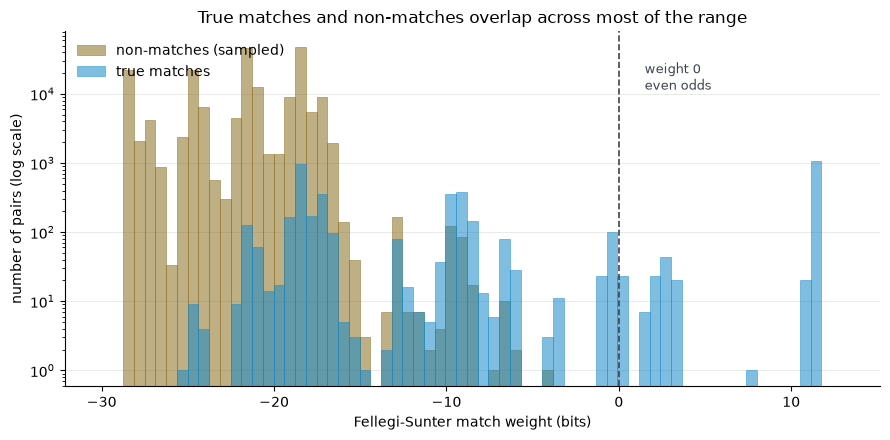

In [6]:
import matplotlib.pyplot as plt

NON_MATCH, MATCH, RULE = "#8c6d1f", "#1789c9", "#3d4451"

lo = min(non_matches["weight"].min(), matches["weight"].min())
hi = max(non_matches["weight"].max(), matches["weight"].max())
bins = np.linspace(np.floor(lo) - 1, np.ceil(hi) + 1, 70)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(non_matches["weight"], bins=bins, color=NON_MATCH, alpha=0.55,
        edgecolor=NON_MATCH, linewidth=0.6, label="non-matches (sampled)")
ax.hist(matches["weight"], bins=bins, color=MATCH, alpha=0.55,
        edgecolor=MATCH, linewidth=0.6, label="true matches")
ax.axvline(0, color=RULE, linestyle="--", linewidth=1.2)
ax.annotate("weight 0\neven odds", xy=(0, ax.get_ylim()[1]), xytext=(1.5, 3e4),
            color=RULE, fontsize=9, va="top")

ax.set_yscale("log")
ax.set_xlabel("Fellegi-Sunter match weight (bits)")
ax.set_ylabel("number of pairs (log scale)")
ax.set_title("True matches and non-matches overlap across most of the range")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e6e6e6", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

This is the honest picture, and it is not the tidy two-humped diagram that
textbook illustrations show.

The non-matches form a tight cluster: their weights sit almost entirely between
-28 and -4 bits, with a median around -22. Nothing surprising there.

The true matches are the problem. They are *spread across the whole range*, from
-26 up to +11, with a median of about -9. Only a minority of them score above
zero. The two populations overlap heavily, and a large share of genuine matches
sits squarely inside the region where the non-matches live.

That is not a failure of the framework. It is the framework telling you the
truth about this data: for most of these pairs, the identifying fields do not
agree, so the evidence for a match genuinely is not there. Under **exact**
comparison, those matches are unrecoverable — and every method in this chapter so
far has used exact comparison.

Hold that thought; section 7 quantifies it and it is the hinge of the whole
section.

## 7. Choosing a threshold

A threshold turns the score back into a decision. Sweep it and watch the
trade-off directly.

In [7]:
rows = []
for t in [-25, -20, -15, -10, -5, 0, 2, 5, 10]:
    tp = int((matches["weight"] >= t).sum())
    # scale the sampled non-matches up to the full cross product
    scale = (len(fonasa) * len(suseso) - TRUE_MATCHES) / len(non_matches)
    fp = float((non_matches["weight"] >= t).sum()) * scale
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall = tp / TRUE_MATCHES
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    rows.append({"threshold_bits": t, "true_positives": tp,
                 "est_false_positives": round(fp),
                 "precision": round(precision, 4), "recall": round(recall, 4),
                 "f1": round(f1, 4)})

pd.DataFrame(rows)

,threshold_bits,true_positives,est_false_positives,precision,recall,f1
0,-25,4499,682545484,0.0000,0.9998,0.0000
1,-20,4268,298676677,0.0000,0.9484,0.0000
2,-15,2500,1757708,0.0014,0.5556,0.0028
3,-10,2310,882904,0.0026,0.5133,0.0052
4,-5,1343,4050,0.2490,0.2984,0.2715
5,0,1205,0,1.0000,0.2678,0.4224
6,2,1173,0,1.0000,0.2607,0.4135
7,5,1088,0,1.0000,0.2418,0.3894
8,10,1087,0,1.0000,0.2416,0.3891


First, a note on the `est_false_positives` column: the non-matches here are a
sample, so counts are scaled up to what the full cross product of 810 million
pairs would produce. At permissive thresholds the number becomes enormous, which
is the correct answer, not an artefact — a low false-positive rate per pair,
applied to 810 million pairs, is a great many false matches.

Now the result that matters, and it is not the flattering one.

The best row sits at a threshold of 0 bits: precision 1.0000, recall 0.2678,
F1 0.4224. The best deterministic rule in the previous notebook managed precision
0.9813 and recall 0.2567.

**The Fellegi-Sunter model, built properly, barely beat a hand-written rule.**

That deserves an explanation rather than an excuse. The framework has given us
something real — a continuous dial instead of five discrete rules, weights
derived from the data instead of judgement, and a principled treatment of
disagreement — but it has not moved the ceiling, because it is still comparing
values for **exact equality**. `GONZALES` and `GONZALEZ` are as different to this
model as `GONZALES` and `MARTINEZ`. When only a third of true matches agree
exactly on a given name, no amount of clever weighting recovers the other two
thirds.

The scoring framework is necessary but not sufficient. What unlocks it is
comparing values that are *similar* rather than identical: string-similarity
measures with several levels of partial agreement, and phonetic encoding so that
names that sound alike compare alike. That is what
[chapter 2.6](implementing-in-splink.md) adds, and it is where the recall on this
data finally moves.

## 8. Weights are probabilities in disguise

A match weight converts directly into a posterior probability that the pair is a
match:

$$P(\text{match}) = \frac{2^{W}}{1 + 2^{W}}$$

This is the number Splink reports as `match_probability`, and it is what
thresholds are usually expressed in.

In [8]:
for w in [-5, 0, 5, 10, 20, 30]:
    p = 2.0 ** w / (1 + 2.0 ** w)
    print(f"match weight {w:>3} bits  ->  probability {p:.6f}")

match weight  -5 bits  ->  probability 0.030303
match weight   0 bits  ->  probability 0.500000
match weight   5 bits  ->  probability 0.969697
match weight  10 bits  ->  probability 0.999024
match weight  20 bits  ->  probability 0.999999
match weight  30 bits  ->  probability 1.000000


Weight 0 is the point of even odds. Note how quickly probability saturates:
by 10 bits a pair is already at 0.999, so differences between 20 and 30 bits are
invisible on the probability scale even though they are large differences in
evidence. When inspecting a model, the weight scale is usually more informative.

## 9. The assumption underneath

Adding field weights together is only valid if the fields are **conditionally
independent** — if, given that a pair is a match, agreement on one field tells
you nothing about whether another agrees.

That assumption is almost always false, and it is worth seeing how false.

In [9]:
a_ap1, _, _ = agreement(matches, "ap1_clean")
a_ap2, _, _ = agreement(matches, "ap2_clean")

both = int((a_ap1 & a_ap2).sum())
expected_if_independent = a_ap1.mean() * a_ap2.mean() * len(matches)

print("Among true matches:")
print(f"  agree on first surname       : {a_ap1.mean():.4f}")
print(f"  agree on second surname      : {a_ap2.mean():.4f}")
print(f"  agree on both, observed      : {both:,} pairs ({both/len(matches):.4f})")
print(f"  agree on both, if independent: {expected_if_independent:,.0f} pairs "
      f"({a_ap1.mean()*a_ap2.mean():.4f})")
print()
print(f"  observed / expected: {both/expected_if_independent:.2f}x")

Among true matches:
  agree on first surname       : 0.4104
  agree on second surname      : 0.3953
  agree on both, observed      : 1,244 pairs (0.2764)
  agree on both, if independent: 730 pairs (0.1623)

  observed / expected: 1.70x


The two surnames agree together far more often than independence would predict.
That is not surprising: a record entered carefully tends to be right in every
field, and a record entered badly tends to be wrong in several. Errors cluster
by record, not by field.

The consequence is that the model **double-counts** correlated evidence and
becomes overconfident: pairs agreeing on both surnames receive a higher weight
than the evidence really justifies, and the reported probabilities are more
extreme than the truth.

This is a known and accepted limitation of the Fellegi-Sunter framework rather
than a defect in your implementation. It is also the reason a model's output
should be evaluated empirically — [chapter 2.8](evaluation.md) — rather than trusted because the
mathematics is correct. Two practical mitigations exist and both appear later:
avoid including several fields that are near-duplicates of each other, and use
term-frequency adjustments so that agreement on a common value is not treated
like agreement on a rare one.

## What you have built

A working probabilistic linkage model, from counting:

- *m* and *u* estimated per field
- weights derived from them, positive for agreement, negative for disagreement
- a total score per pair, on an interpretable scale
- a threshold that makes the precision/recall trade-off explicit and continuous
- a known violated assumption, and a sense of which way it errs

Three things are still missing, and they are what a linkage library provides.

**Estimating *m* without a ground truth.** Nobody has the answer key. Chapter 2.6
uses expectation-maximisation to estimate *m* from the data itself.

**Comparing values that are similar rather than identical.** Everything here was
exact agreement, so `GONZALES` and `GONZALEZ` still count as a disagreement.
Real comparisons use string similarity and phonetic encoding, with several
levels of partial agreement rather than two.

**Not scoring 810 million pairs.** This notebook only scored 4,500 matches and a
sample. Scoring every pair is infeasible at national scale, and
[chapter 2.5](blocking.md) is about how to avoid it without losing the matches
you were looking for.